# Exploratory Data Analysis Summary

This document summarizes the key findings from the exploratory data analysis (EDA) conducted on the well log dataset. The goals are to identify the well distribution, the most relevant logs for geological and geophysical analysis, and to understand their distributions and characteristics.

## Data Cleaning

We first cleaned the dataset by removing invalid or outlier values based on known physical limits for each log type, they originate from service-company chart conventions and API-RP standards used in well-log presentation. There isn’t a single unified “official” API table, but the standard values are consistent across the main service-company manuals. The table below summarizes the cleaning criteria applied to each log type.

| name | name extended | scale | unit |
|------|----------------|-------|------|
| GR   | Gamma Ray      | 0 - 150 | API  |
| SP   | Spontaneous Potential | -100 to +100 | mV   |
| DT   | Sonic (Compressional slowness) | 40 - 140 | µs/ft |
| CALI | Caliper        | 6 - 16 | inches |
| ILD  | Deep Induction Resistivity | 0.2 - 2000 (logarithmic scale) | ohm·m |
| RHOB | Bulk Density | 1.95 - 2.95 | g/cm³ |
| NPHI | Neutron Porosity | 0 - 0.45 (sometimes plotted reverse, 45-0) | fraction (v/v) |
| MSFL | Micro Spherically Focused Log | 0.2 - 2000 (logarithmic scale) | ohm·m |
| DRHO | Density Correction | -0.1 - +0.3 | g/cm³ |
| SFLU | Shallow Laterolog (Unfocused) | 0.2 - 2000 (logarithmic scale) | ohm·m |

These logs were selected based on how frequently they are present in the dataset and their relevance to common geological interpretations.

The formula below shows how to calculate the paretto chart used for selecting the most frequent log types:

1. Sort the data in descending order.
2. Calculate the cumulative sum of the values.
3. Calculate the cumulative percentage of the total.
4. Plot the sorted values as bars and the cumulative percentage as a line.

$$y_i = \frac{x_i}{\sum_{j=1}^{n} x_j} \times 100$$

In [2]:
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
from scipy import stats

conn = sqlite3.connect('../slide/database/features.db')
query = "SELECT * FROM Features"
df_features = pd.read_sql_query(query, conn)
df_features.info()

"""
select 
	count(*) AS t,
	CASE WHEN LOWER(name) LIKE "%.dlis" THEN "dlis"
	WHEN LOWER(name) LIKE "%.lis" THEN "lis"
	WHEN LOWER(name) LIKE "%.las" THEN "las"
	WHEN LOWER(name) LIKE "%.tif" THEN "tif"
	ELSE "other" END AS type
from logs group by 2 order by 1 desc;
"""

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21219468 entries, 0 to 21219467
Data columns (total 15 columns):
 #   Column  Dtype  
---  ------  -----  
 0   well    object 
 1   depth   float64
 2   GR      float64
 3   SP      float64
 4   DT      float64
 5   CALI    float64
 6   ILD     float64
 7   RHOB    float64
 8   NPHI    float64
 9   MSFL    float64
 10  DRHO    float64
 11  SFLU    float64
 12  top     float64
 13  bottom  float64
 14  rock    object 
dtypes: float64(13), object(2)
memory usage: 2.4+ GB


'\nselect \n\tcount(*) AS t,\n\tCASE WHEN LOWER(name) LIKE "%.dlis" THEN "dlis"\n\tWHEN LOWER(name) LIKE "%.lis" THEN "lis"\n\tWHEN LOWER(name) LIKE "%.las" THEN "las"\n\tWHEN LOWER(name) LIKE "%.tif" THEN "tif"\n\tELSE "other" END AS type\nfrom logs group by 2 order by 1 desc;\n'

In [3]:
target_column = 'rock'
features_columns = [
        'depth',
        'top',
        'GR', 
        'SP', 
        'DT', 
        'CALI', 
        'ILD', 
        'RHOB', 
        'NPHI', 
        'MSFL',
        'DRHO', 
        'SFLU']
valid_rocks = [
    'FOLHELHO', 'ARENITO', 'SILTITO', 'CALCILUTITO', 'AREIA', 'CALCARENITO',
    'ARGILA', 'CALCARIO', 'CONGLOMERADO', 'ARGILITO', 'ANIDRITA', 'MARGA',
    'GRANITO', 'BASALTO', 'DOLOMITO'
]
numeric_columns = df_features.select_dtypes(include=[np.number]).columns

df_features_filtered = df_features.copy()

# Replace outliers with NaN
for col in numeric_columns:
    if col == "GR":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 0) | (df_features_filtered[col] > 150), np.nan, df_features_filtered[col])
    elif col == "SP":
        df_features_filtered[col] = np.where((df_features_filtered[col] < -100) | (df_features_filtered[col] > 100), np.nan, df_features_filtered[col])
    elif col == "DT":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 40) | (df_features_filtered[col] > 140), np.nan, df_features_filtered[col])
    elif col == "CALI":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 6) | (df_features_filtered[col] > 16), np.nan, df_features_filtered[col])
    elif col == "ILD":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 0.2) | (df_features_filtered[col] > 2000), np.nan, df_features_filtered[col])
    elif col == "RHOB":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 1.95) | (df_features_filtered[col] > 2.95), np.nan, df_features_filtered[col])
    elif col == "NPHI":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 0) | (df_features_filtered[col] > 0.45), np.nan, df_features_filtered[col])
    elif col == "MSFL":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 0.2) | (df_features_filtered[col] > 2000), np.nan, df_features_filtered[col])
    elif col == "DRHO":
        df_features_filtered[col] = np.where((df_features_filtered[col] < -0.1) | (df_features_filtered[col] > 0.3), np.nan, df_features_filtered[col])
    elif col == "SFLU":
        df_features_filtered[col] = np.where((df_features_filtered[col] < 0.2) | (df_features_filtered[col] > 2000), np.nan, df_features_filtered[col])

df_features_filtered["rock"] = np.where(df_features_filtered['rock'].isin(valid_rocks), df_features_filtered["rock"], np.nan)
df_features_filtered.describe()


,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,DRHO,SFLU,top,bottom
count,2.121947e+07,1.360677e+07,1.294828e+07,9.358043e+06,1.014187e+07,9.827687e+06,6.892769e+06,869791.000000,3.320743e+06,7.034489e+06,4.914195e+06,1.826859e+07,1.826859e+07
mean,1.954251e+03,6.772899e+01,-1.438126e-01,8.428989e+01,1.037147e+01,3.728009e+01,2.422212e+00,0.205850,2.964070e+01,4.639522e-02,6.477084e+01,1.215560e+03,1.256587e+03
std,2.472924e+03,3.327137e+01,4.811358e+01,1.927342e+01,1.982585e+00,1.810354e+02,1.603140e-01,0.108123,1.788598e+02,5.741474e-02,2.772040e+02,9.086263e+02,9.032489e+02
min,-9.642040e+01,0.000000e+00,-1.000000e+02,4.000000e+01,6.000000e+00,2.000508e-01,1.950000e+00,0.000000,2.000283e-01,-9.999999e-02,2.000353e-01,2.000000e+00,6.000000e+00
25%,5.929610e+02,4.275000e+01,-3.769791e+01,6.962894e+01,8.765625e+00,3.381516e+00,2.306412e+00,0.133569,2.094727e+00,6.000000e-03,3.995707e+00,5.040000e+02,5.500000e+02
50%,1.207000e+03,6.875314e+01,-3.755859e+00,8.292969e+01,9.628937e+00,6.472635e+00,2.429029e+00,0.215357,3.740234e+00,2.796936e-02,7.413086e+00,1.016000e+03,1.050000e+03
75%,2.195400e+03,8.962500e+01,3.919077e+01,9.709998e+01,1.214062e+01,1.540527e+01,2.542420e+00,0.278809,9.320312e+00,6.885338e-02,1.824929e+01,1.732000e+03,1.773000e+03
max,1.939616e+04,1.500000e+02,1.000000e+02,1.400000e+02,1.600000e+01,2.000000e+03,2.950000e+00,0.450000,2.000000e+03,3.000000e-01,2.000000e+03,5.858000e+03,5.911000e+03


## Dataset Summary

- Total wells by is_labeled
    - Pie chart
    - Slices: Labeled vs Unlabeled
- Distribution of wells by basin and is_labeled
    - Stacked bar chart
    - X-axis: Basins
    - Y-axis: Distinct Number of wells
    - Different colors for each file type (is_labeled)
    - on top of each bar: percentage of total wells in that basin
- Distribution of wells by Lithology
    - Bar chart
    - X-axis: Lithology
    - Y-axis: Distinct Number of wells
    - on top of each bar: percentage of total wells with that lithology
- Distribution of missing data by log type
    - Stacked Bar chart
    - X-axis: Log Types
    - Y-axis: Total rows
    - Legend: Missing vs Non-Missing
    - On top of each bar: percentage of missing data for that log type
- Correlation matrix of log types
    - Heatmap
    - Color scale indicating correlation strength


- Normal distribution plots for each log type
    - Subplots for each log type
    - X-axis: Log Values
    - Y-axis: Density
- Distribution of log values by log type
    - Subplots with Box plots for each log type
    - X-axis: Log Types
    - Y-axis: Log Values


In [4]:
############## wells, basins and is labeled distribution ##############

import os
import pandas as pd
import sqlite3

conn = sqlite3.connect('../slide/database/download.db')
conn.enable_load_extension(True)
conn.load_extension(f"../slide/database/models/regex0.{'dll' if os.name == 'nt' else 'so'}")

query = """
 WITH LabeledWells AS (
    SELECT DISTINCT
        replace(
            regex_replace(
                '([A-Za-z]*|^0[0-9])0+([A-Za-z0-9])',
                a.well,'$1$2'),
            " ", "") AS well,
        "labeled" AS labeled
    FROM AGPLithology a
    WHERE a.well IS NOT NULL
),
NotLabeledWells AS (
    SELECT DISTINCT
        replace(well,"-","") AS well,
        basin
    FROM logs
)
SELECT
    COUNT(DISTINCT well) AS Wells_Count,
    basin,
    CASE WHEN labeled IS NULL THEN "not labeled" ELSE "labeled" END AS labeled_status
FROM NotLabeledWells LEFT JOIN LabeledWells USING (well)
GROUP BY 2, 3
ORDER BY 1 DESC;
"""
df_wells = pd.read_sql_query(query, conn)
df_wells.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Wells_Count     35 non-null     int64 
 1   basin           35 non-null     object
 2   labeled_status  35 non-null     object
dtypes: int64(1), object(2)
memory usage: 972.0+ bytes


### General dataset statistics

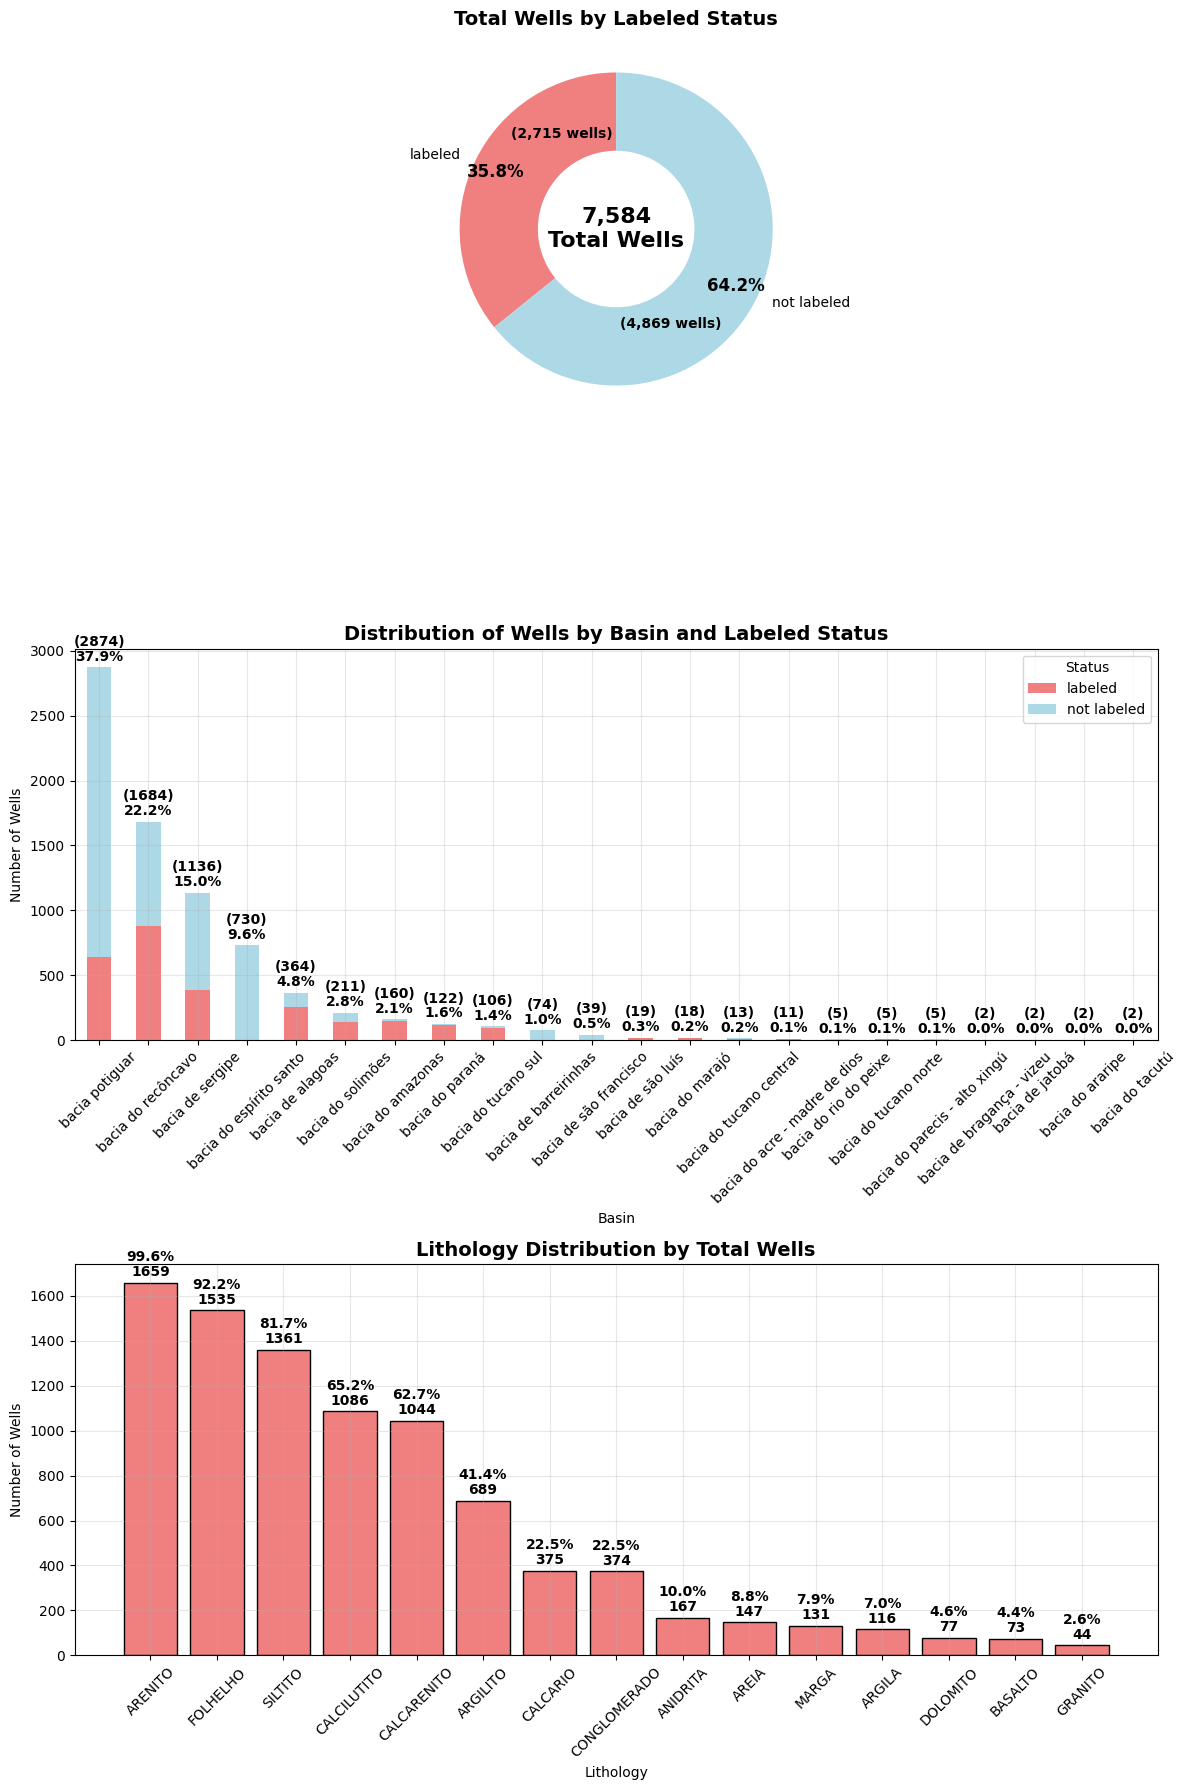

In [5]:
import numpy as np

import matplotlib.pyplot as plt

############################# WELLS DISTRIBUTION CHARTS ##########################
# 1. Pie chart for total wells by labeled_status
labeled_totals = df_wells.groupby('labeled_status')['Wells_Count'].sum()
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Donut chart - first row
ax1 = axes[0]
colors = ['lightcoral', 'lightblue']
wedges, texts, autotexts = ax1.pie(labeled_totals.values, labels=labeled_totals.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90,
                                   pctdistance=0.85, wedgeprops=dict(width=0.5))
ax1.set_title('Total Wells by Labeled Status', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

# Add total wells count in the center
total_wells = labeled_totals.sum()
ax1.text(0, 0, f'{total_wells:,}\nTotal Wells', ha='center', va='center', 
         fontsize=16, fontweight='bold')

# Add well counts below percentages
for i, (label, count) in enumerate(labeled_totals.items()):
    angle = 120 + (i * 180)  # Position text radially
    x = 0.7 * np.cos(np.radians(angle))
    y = 0.7 * np.sin(np.radians(angle))
    ax1.text(x, y, f'({count:,} wells)', ha='center', va='center', 
             fontsize=10, fontweight='bold')

# 2. Stacked bar chart for distribution by basin and labeled_status - second row
ax2 = axes[1]
pivot_data = df_wells.pivot(index='basin', columns='labeled_status', values='Wells_Count').fillna(0)

# Calculate percentages for each basin
basin_totals = pivot_data.sum(axis=1)
pivot_percentages = pivot_data.div(basin_totals, axis=0) * 100

# Sort by total wells (descending order)
pivot_data_sorted = pivot_data.loc[basin_totals.sort_values(ascending=False).index]
basin_totals_sorted = basin_totals.sort_values(ascending=False)

# Create stacked bar chart
pivot_data_sorted.plot(kind='bar', stacked=True, ax=ax2, color=['lightcoral', 'lightblue'])
ax2.set_title('Distribution of Wells by Basin and Labeled Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Basin')
ax2.set_ylabel('Number of Wells')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Status')
ax2.grid(True, alpha=0.3)

# Add percentage labels on top of each bar
for i, (basin, total) in enumerate(basin_totals_sorted.items()):
    percentage = (total / labeled_totals.sum()) * 100
    ax2.text(i, total + max(basin_totals_sorted) * 0.01, f'{percentage:.1f}%', 
             ha='center', va='bottom', fontweight='bold')
    ax2.text(i, total + max(basin_totals_sorted) * 0.05, f'({int(total)})', 
             ha='center', va='bottom', fontweight='bold')

########################## LITHOLOGY DISTRIBUTION CHART ##########################

# Count distinct wells for each rock type
rock_well_counts = df_features_filtered.groupby('rock')['well'].nunique().sort_values(ascending=False)
rock_well_percentages = (rock_well_counts / df_features_filtered['well'].nunique()) * 100

# Create a summary dataframe
rock_well_distribution = pd.DataFrame({
    'Rock_Type': rock_well_counts.index,
    'Wells_Count': rock_well_counts.values,
    'Wells_Percentage': rock_well_percentages.values
})

# Bar chart for lithology distribution - third row
ax3 = axes[2]
ax3.bar(rock_well_distribution['Rock_Type'], rock_well_distribution['Wells_Count'], 
        color='lightcoral', edgecolor='black')
ax3.set_title('Lithology Distribution by Total Wells', fontsize=14, fontweight='bold')
ax3.set_xlabel('Lithology')
ax3.set_ylabel('Number of Wells')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# Add count labels on bars
for i, v in enumerate(rock_well_distribution['Wells_Count']):
    ax3.text(i, v + max(rock_well_distribution['Wells_Count']) * 0.01, str(v), 
             ha='center', va='bottom', fontweight='bold')
    ax3.text(i, v + max(rock_well_distribution['Wells_Count']) * 0.05, 
             f"{rock_well_distribution['Wells_Percentage'][i]:.1f}%", 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [6]:
########################## SUMMARY WELLS DISTRIBUTION ##################

# Print summary statistics
print("Wells Distribution Summary:")
print("=" * 40)
print(f"Total wells: {labeled_totals.sum()}")
print(f"Labeled wells: {labeled_totals['labeled']} ({labeled_totals['labeled']/labeled_totals.sum()*100:.1f}%)")
print(f"Not labeled wells: {labeled_totals['not labeled']} ({labeled_totals['not labeled']/labeled_totals.sum()*100:.1f}%)")
print("\nTop 5 basins by total wells:")
print(basin_totals.sort_values(ascending=False).head())


########################### Lithology Distribution Summary ##########################
# Print summary statistics
print("Lithology Distribution Summary:")
print("=" * 40)
print(f"Total data points: {df_features_filtered['rock'].count():,}")

Wells Distribution Summary:
Total wells: 7584
Labeled wells: 2715 (35.8%)
Not labeled wells: 4869 (64.2%)

Top 5 basins by total wells:
basin
bacia potiguar             2874.0
bacia do recôncavo         1684.0
bacia de sergipe           1136.0
bacia do espírito santo     730.0
bacia de alagoas            364.0
dtype: float64
Lithology Distribution Summary:
Total data points: 17,791,219


### Plot Log Distribution Charts

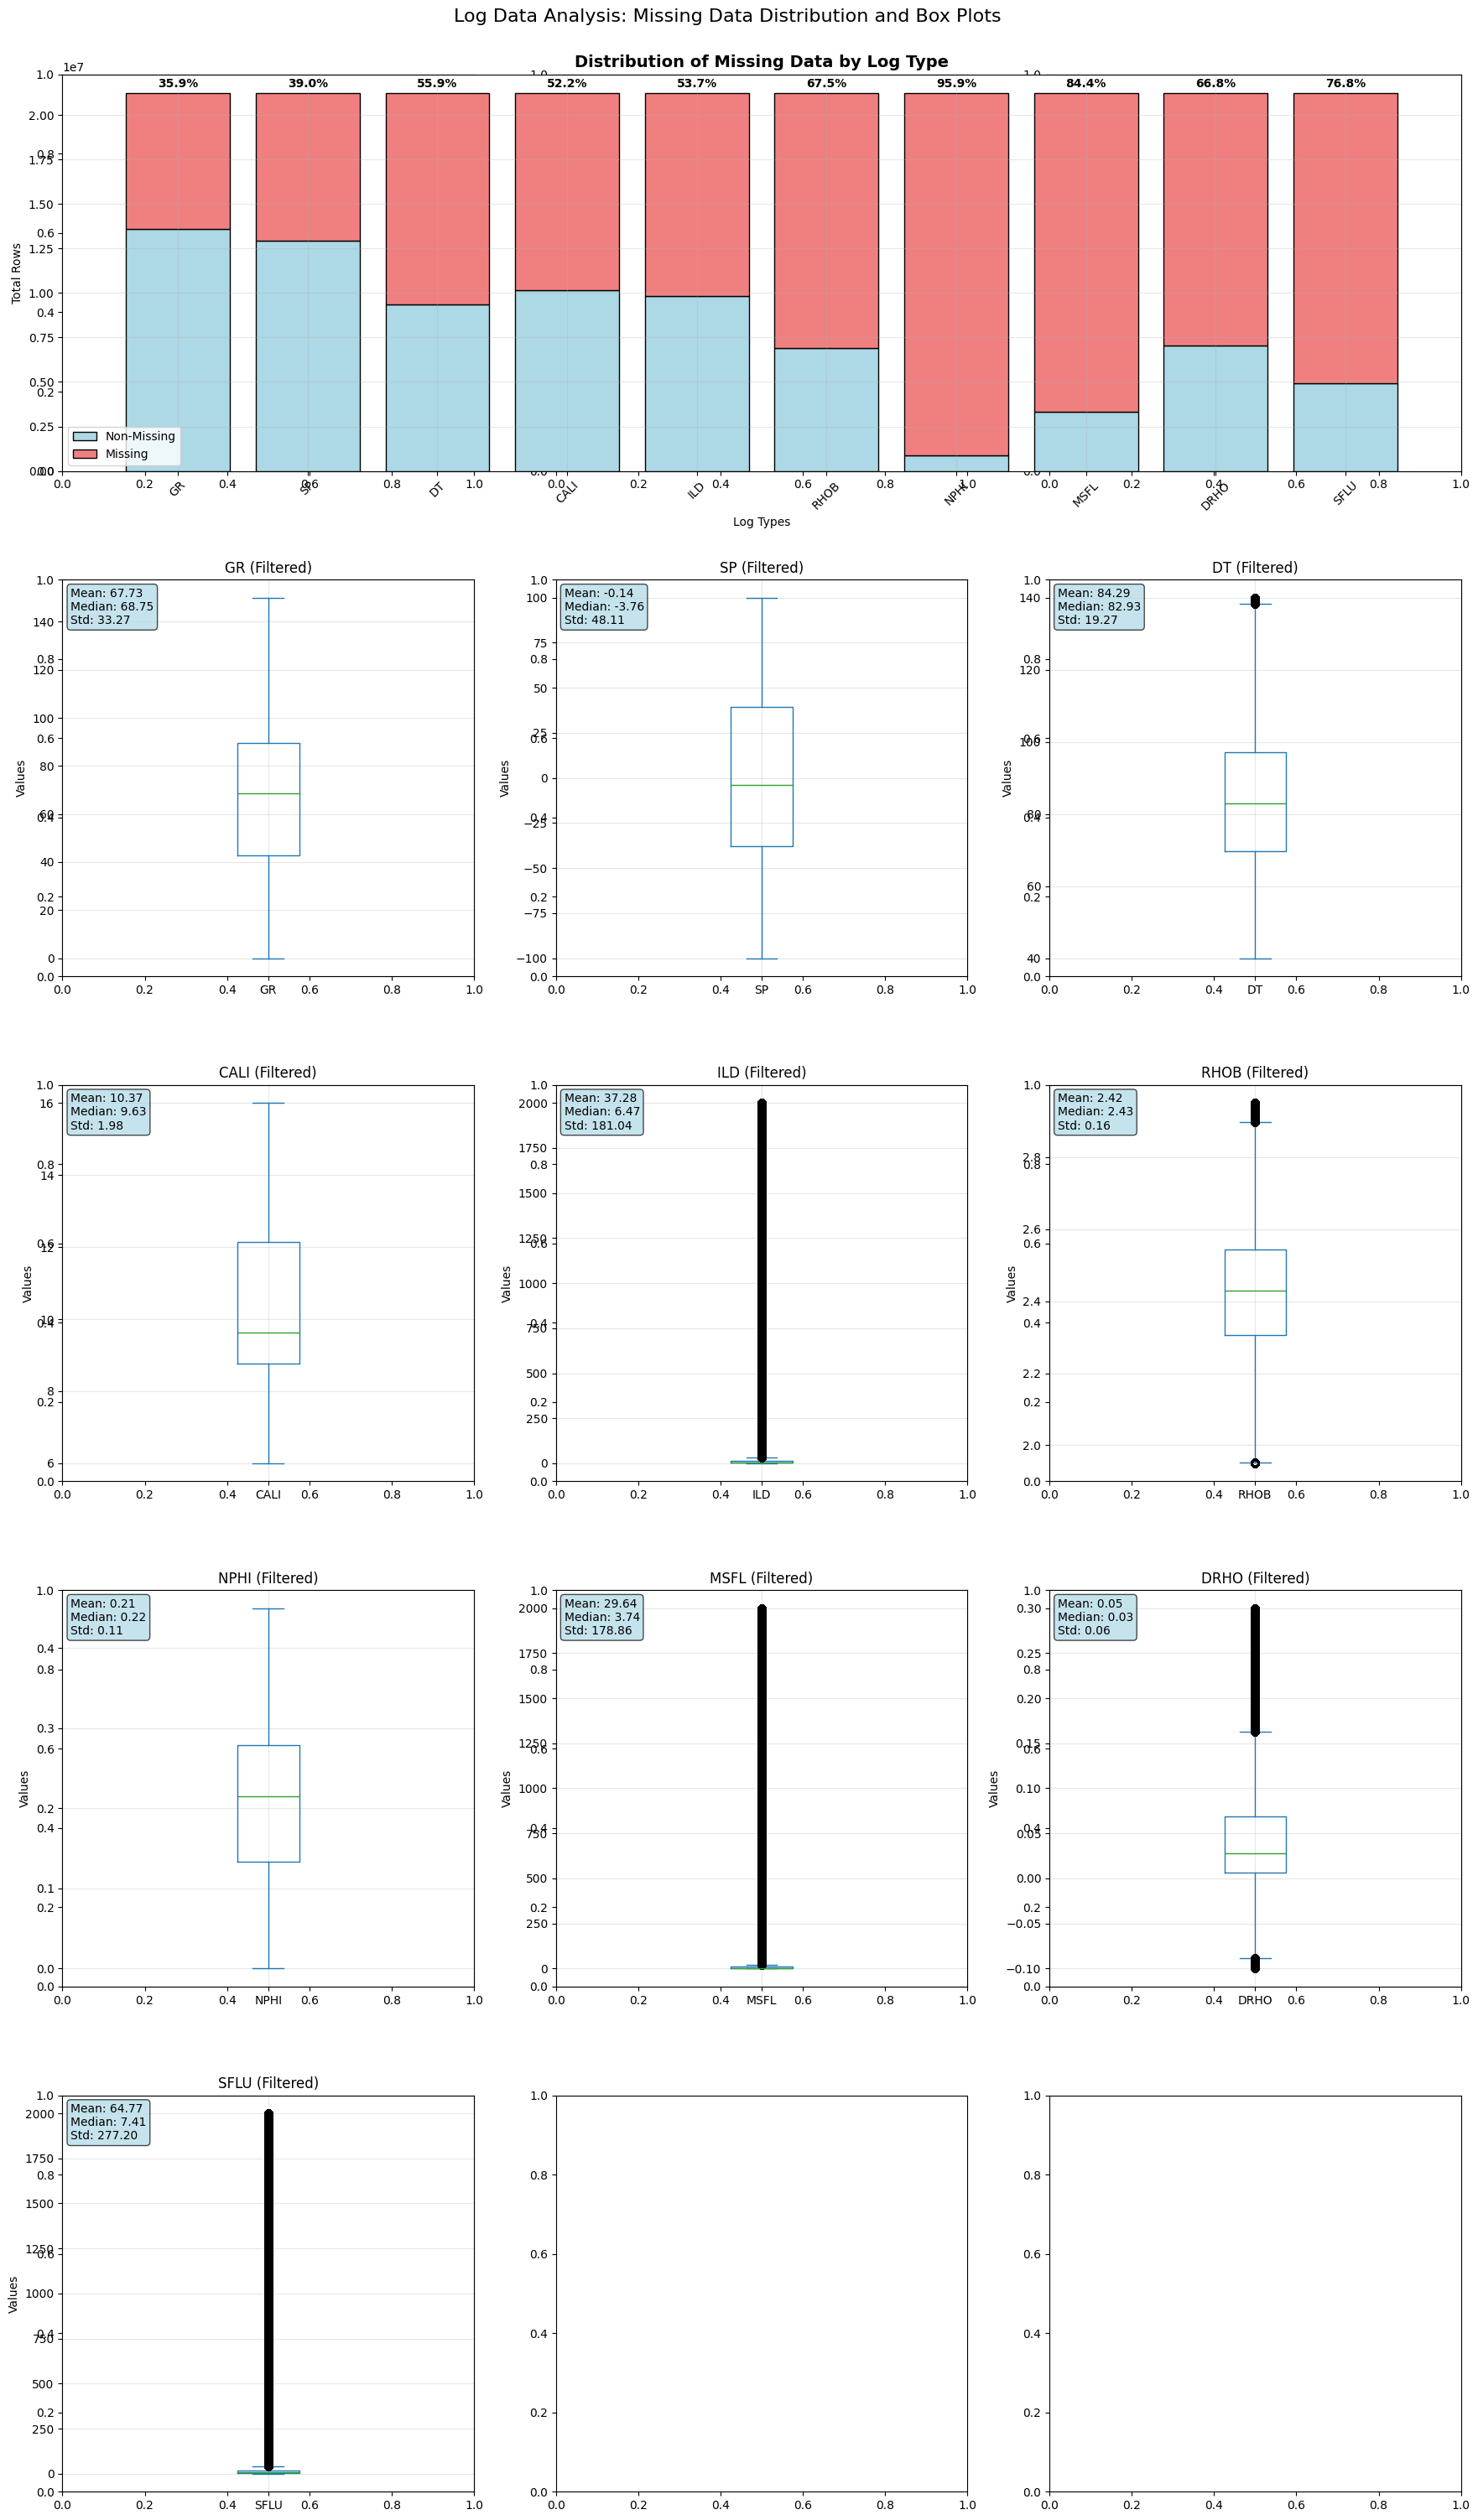

In [10]:
########################## MISSING DATA DISTRIBUTION ##########################
# 1. Distribution of missing data by log type
missing_data_analysis = []

for col in features_columns:
    if col in ['depth', 'top']:  # Skip depth and top as they're not log types
        continue
    
    total_rows = len(df_features_filtered)
    missing_count = df_features_filtered[col].isna().sum()
    non_missing_count = total_rows - missing_count
    missing_percentage = (missing_count / total_rows) * 100
    
    missing_data_analysis.append({
        'Log_Type': col,
        'Missing': missing_count,
        'Non_Missing': non_missing_count,
        'Missing_Percentage': missing_percentage
    })

missing_df = pd.DataFrame(missing_data_analysis)

################################ BOX PLOTS ##########################

columns_to_exclude = ['depth', 'top', 'bottom', 'well']
filtered_numeric_columns = [col for col in numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

# Create box plots for the filtered numeric columns (excluding depth, top, bottom)
filtered_numeric_columns_clean = [col for col in filtered_numeric_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

n_cols_clean = len(filtered_numeric_columns_clean)
n_rows_clean = (n_cols_clean + 2) // 3  # 3 columns per row

# Create figure with missing data chart at top and box plots at bottom
fig, axes = plt.subplots(n_rows_clean + 1, 3, figsize=(18, 6 * (n_rows_clean + 1)))
fig.suptitle('Log Data Analysis: Missing Data Distribution and Box Plots', fontsize=16, y=1)

# Missing data distribution chart - spans all 3 columns in first row
ax_missing = plt.subplot2grid((n_rows_clean + 1, 3), (0, 0), colspan=3)

log_types = missing_df['Log_Type']
missing_counts = missing_df['Missing']
non_missing_counts = missing_df['Non_Missing']

# Stacked bar chart
ax_missing.bar(log_types, non_missing_counts, label='Non-Missing', color='lightblue', edgecolor='black')
ax_missing.bar(log_types, missing_counts, bottom=non_missing_counts, label='Missing', color='lightcoral', edgecolor='black')

ax_missing.set_title('Distribution of Missing Data by Log Type', fontsize=14, fontweight='bold')
ax_missing.set_xlabel('Log Types')
ax_missing.set_ylabel('Total Rows')
ax_missing.legend()
ax_missing.grid(True, alpha=0.3)
ax_missing.tick_params(axis='x', rotation=45)

# Add percentage labels on top of each bar
for i, row in missing_df.iterrows():
    total_height = row['Missing'] + row['Non_Missing']
    ax_missing.text(i, total_height + max(missing_df['Missing'] + missing_df['Non_Missing']) * 0.01, 
                   f'{row["Missing_Percentage"]:.1f}%', 
                   ha='center', va='bottom', fontweight='bold')

# Box plots - starting from second row
for i, col in enumerate(filtered_numeric_columns_clean):
    row = (i // 3) + 1  # Start from row 1 (second row)
    col_pos = i % 3
    ax = plt.subplot2grid((n_rows_clean + 1, 3), (row, col_pos))
    
    # Create box plot
    df_features_filtered[col].plot(kind='box', ax=ax, title=f'{col} (Filtered)')
    ax.set_ylabel('Values')
    ax.grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f'Mean: {df_features_filtered[col].mean():.2f}\nMedian: {df_features_filtered[col].median():.2f}\nStd: {df_features_filtered[col].std():.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()


In [11]:
######################### Missing Data Summary ##################

print("\nMissing Data Summary:")
print("=" * 40)
for _, row in missing_df.iterrows():
    print(f"{row['Log_Type']}: {row['Missing_Percentage']:.1f}% missing ({row['Missing']:,} out of {row['Missing'] + row['Non_Missing']:,})")



Missing Data Summary:
GR: 35.9% missing (7,612,695 out of 21,219,468)
SP: 39.0% missing (8,271,184 out of 21,219,468)
DT: 55.9% missing (11,861,425 out of 21,219,468)
CALI: 52.2% missing (11,077,596 out of 21,219,468)
ILD: 53.7% missing (11,391,781 out of 21,219,468)
RHOB: 67.5% missing (14,326,699 out of 21,219,468)
NPHI: 95.9% missing (20,349,677 out of 21,219,468)
MSFL: 84.4% missing (17,898,725 out of 21,219,468)
DRHO: 66.8% missing (14,184,979 out of 21,219,468)
SFLU: 76.8% missing (16,305,273 out of 21,219,468)


### Plot Log Bell Curves

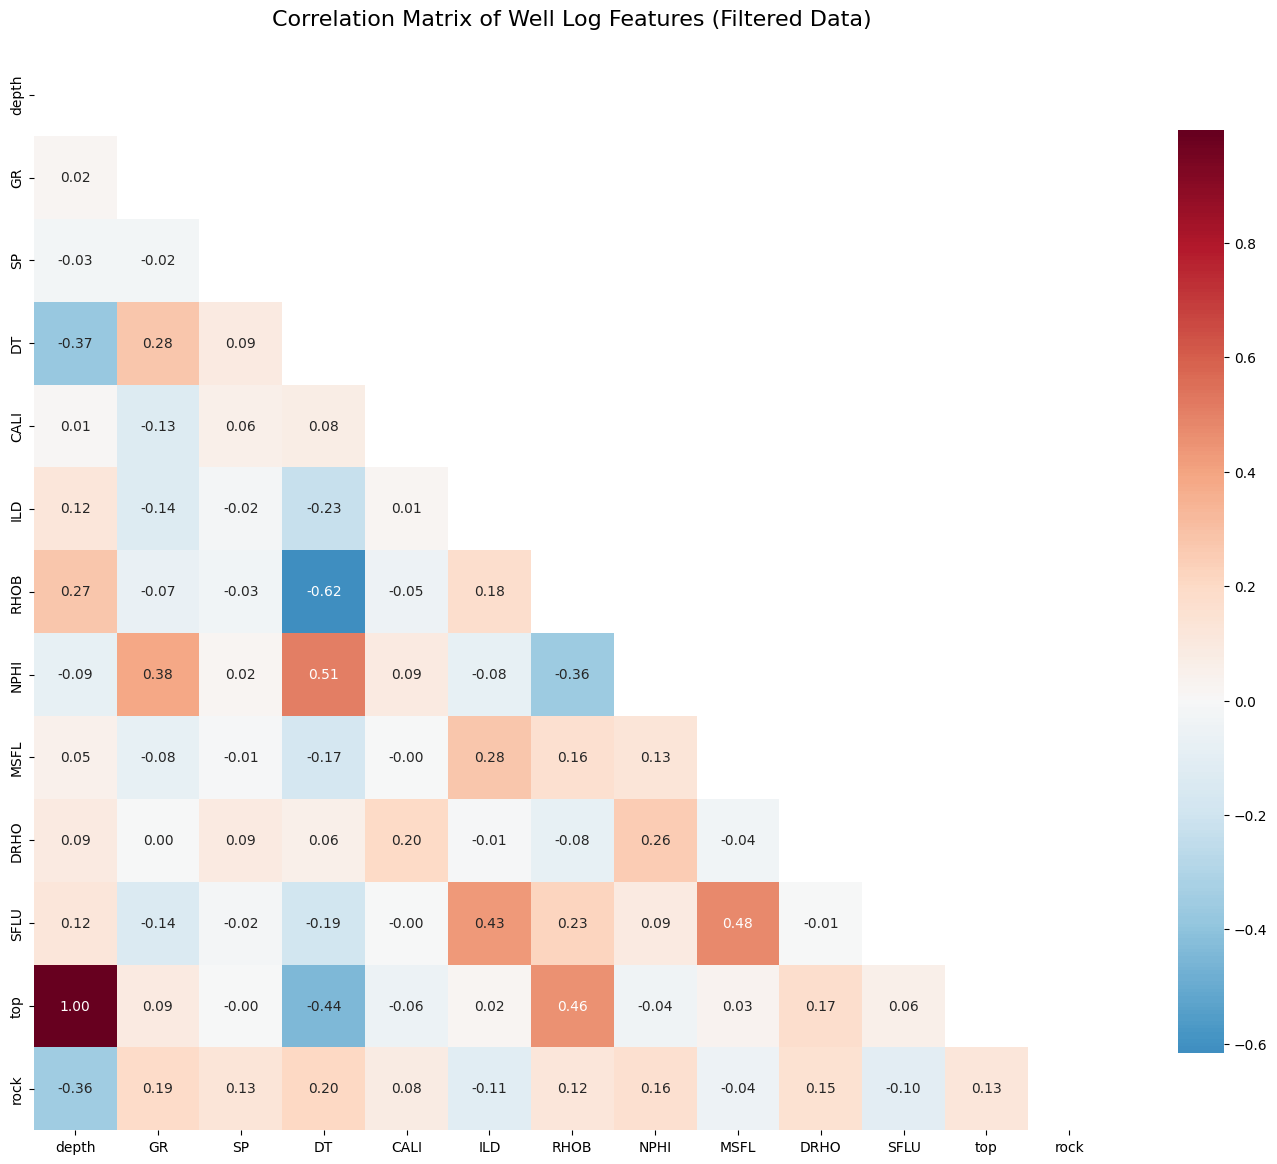

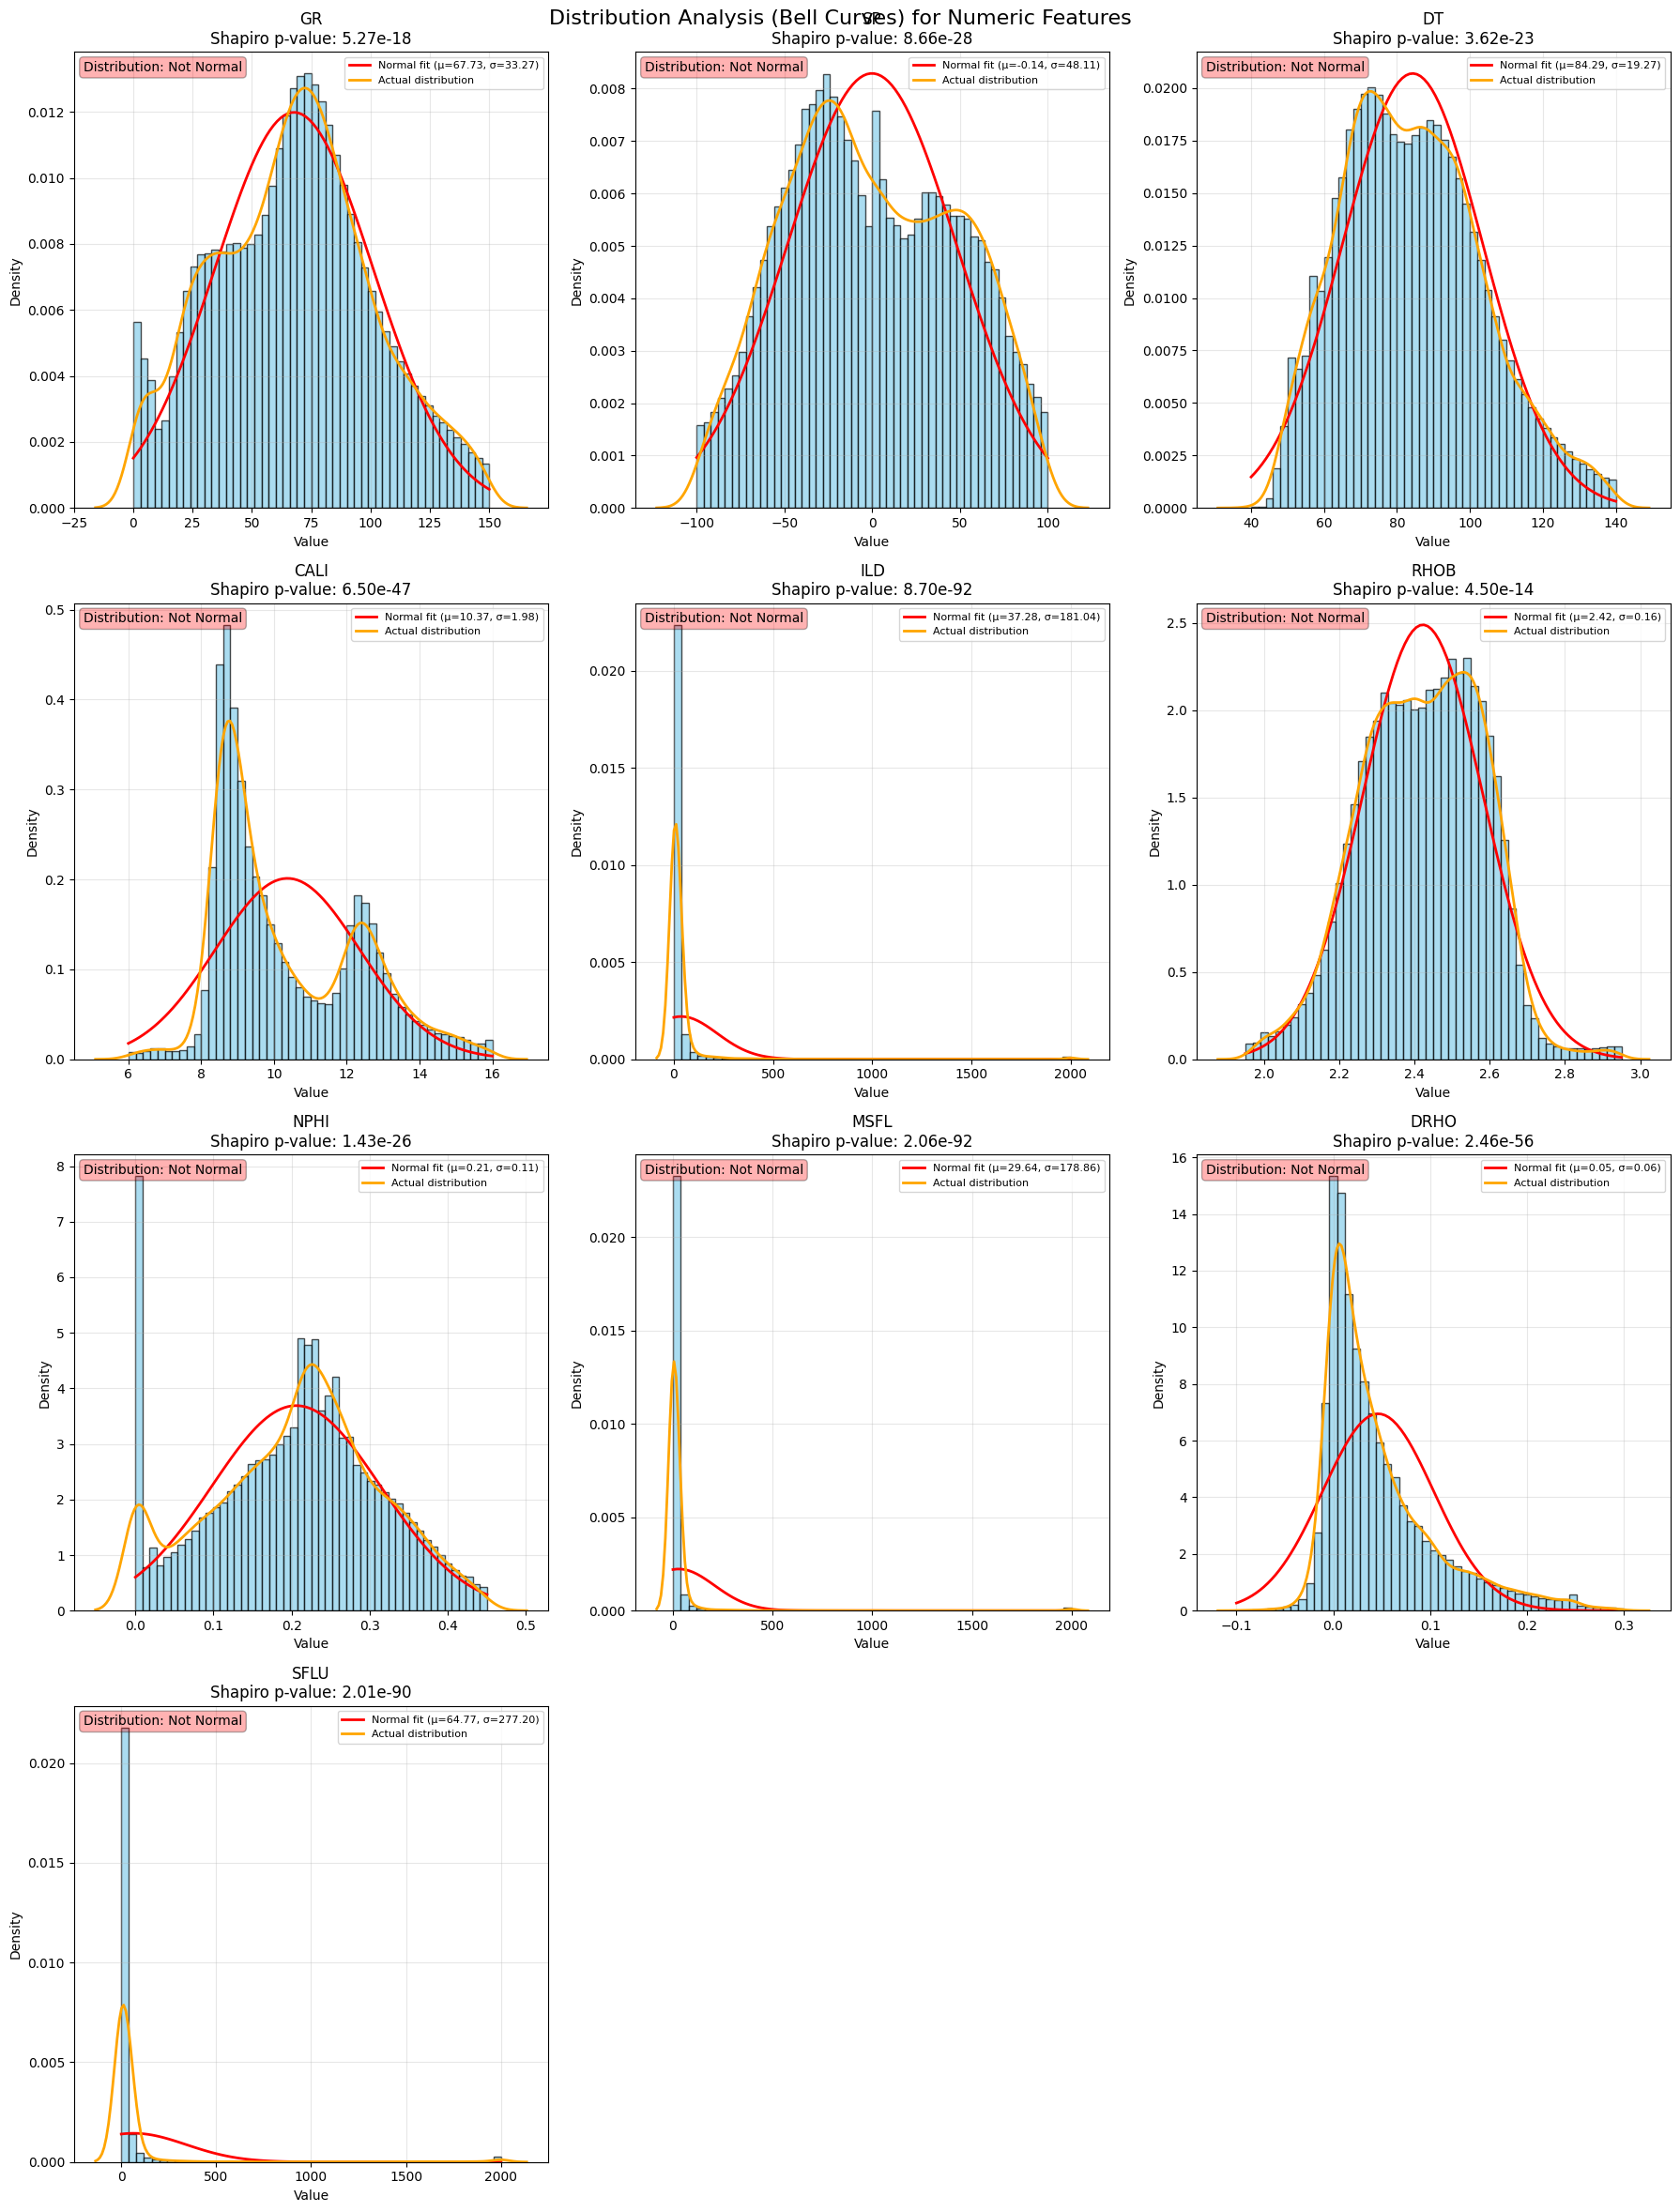

In [12]:
import seaborn as sns
from scipy import stats

# Create histograms (bell curves) to check for normal distribution
import matplotlib.pyplot as plt

########################## CORRELATION MATRIX ##########################

# Create correlation matrix for numeric columns in the filtered dataset
columns = df_features_filtered.columns.copy()
columns = columns.drop(["well", "bottom"])
df_features_cleaned = df_features_filtered.copy()
df_features_cleaned["rock"] = df_features_filtered["rock"].astype('category').cat.codes
correlation_matrix = df_features_cleaned[columns].corr()

# Create heatmap using matplotlib and seaborn
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Well Log Features (Filtered Data)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

############################ BELL CURVES          #########################

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Calculate number of filtered numeric columns and create subplots
n_cols_dist = len(filtered_numeric_columns_clean)
n_rows_dist = (n_cols_dist + 2) // 3  # 3 columns per row
fig, axes = plt.subplots(n_rows_dist, 3, figsize=(18, 6 * n_rows_dist))
fig.suptitle('Distribution Analysis (Bell Curves) for Numeric Features', fontsize=16, y=0.98)

# Handle single subplot case
if n_cols_dist == 1:
    axes = [axes]
elif n_rows_dist == 1:
    axes = axes if n_cols_dist > 1 else [axes]
else:
    axes = axes.flatten()

# Create distribution plots
for i, col in enumerate(filtered_numeric_columns_clean):
    ax = axes[i] if n_cols_dist > 1 else axes[0]
    
    # Get data for the column (remove NaN values)
    data = df_features_filtered[col].dropna()
    
    if len(data) > 0:
        # Create histogram with density curve
        ax.hist(data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        
        # Overlay normal distribution curve
        mu, sigma = stats.norm.fit(data)
        x = np.linspace(data.min(), data.max(), 100)
        normal_curve = stats.norm.pdf(x, mu, sigma)
        ax.plot(x, normal_curve, 'r-', linewidth=2, label=f'Normal fit (μ={mu:.2f}, σ={sigma:.2f})')
        
        # Overlay actual kernel density estimate
        data_sample = data.sample(min(10000, len(data)))  # Sample for performance
        sns.kdeplot(data=data_sample, ax=ax, color='orange', linewidth=2, label='Actual distribution')
        
        # Perform Shapiro-Wilk test for normality (on sample if data is large)
        sample_size = min(5000, len(data))  # Shapiro-Wilk works best with smaller samples
        data_sample_test = data.sample(sample_size) if len(data) > sample_size else data
        shapiro_stat, shapiro_p = stats.shapiro(data_sample_test)
        
        # Set title and labels
        ax.set_title(f'{col}\nShapiro p-value: {shapiro_p:.2e}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Add interpretation text
        if shapiro_p > 0.05:
            normality_text = "Likely Normal"
            text_color = 'green'
        else:
            normality_text = "Not Normal"
            text_color = 'red'
        
        ax.text(0.02, 0.98, f'Distribution: {normality_text}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor=text_color, alpha=0.3))
    else:
        ax.text(0.5, 0.5, f'No data available for {col}', 
                transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f'{col} - No Data')

# Hide unused subplots
for i in range(len(filtered_numeric_columns_clean), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()



In [13]:
#######################################  Correlation Summary  #######################################
# Print strong correlations (absolute value > 0.7)
print("=" * 50)
strong_corr = []
normal_corr = []
weak_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            strong_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })
        elif abs(corr_value) > 0.4:
            normal_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })
        elif abs(corr_value) > 0.1:
            weak_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
    print(strong_corr_df)
else:
    print("No strong correlations found (|r| > 0.7)")
    
if normal_corr:
    normal_corr_df = pd.DataFrame(normal_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\nNormal Correlations (|r| > 0.4):")
    print(normal_corr_df)
else:
    print("No normal correlations found (|r| > 0.4)")
if weak_corr:
    weak_corr_df = pd.DataFrame(weak_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\nWeak Correlations (|r| > 0.1):")
    print(weak_corr_df)
else:
    print("No weak correlations found (|r| > 0.1)")





#######################################  Normality Test Summary  #######################################



# Print summary of normality tests
print("\nNormality Test Summary:")
print("=" * 50)
print("Shapiro-Wilk Test Results (p > 0.05 suggests normal distribution):\n")

normality_results = []
for col in filtered_numeric_columns_clean:
    data = df_features_filtered[col].dropna()
    if len(data) > 3:  # Minimum required for Shapiro-Wilk
        sample_size = min(5000, len(data))
        data_sample = data.sample(sample_size) if len(data) > sample_size else data
        shapiro_stat, shapiro_p = stats.shapiro(data_sample)
        
        normality_results.append({
            'Feature': col,
            'Sample_Size': len(data_sample),
            'Shapiro_Statistic': shapiro_stat,
            'P_Value': shapiro_p,
            'Is_Normal': 'Yes' if shapiro_p > 0.05 else 'No'
        })

normality_df = pd.DataFrame(normality_results)
print(normality_df.round(6))

  Feature 1 Feature 2  Correlation
0     depth       top     0.996653

Normal Correlations (|r| > 0.4):
  Feature 1 Feature 2  Correlation
0        DT      RHOB    -0.616616
1        DT      NPHI     0.508030
5      MSFL      SFLU     0.478711
4      RHOB       top     0.458236
2        DT       top    -0.444471
3       ILD      SFLU     0.430823

Weak Correlations (|r| > 0.1):
   Feature 1 Feature 2  Correlation
8         GR      NPHI     0.384336
0      depth        DT    -0.371229
20      RHOB      NPHI    -0.364154
4      depth      rock    -0.357265
5         GR        DT     0.277395
18       ILD      MSFL     0.275742
2      depth      RHOB     0.274011
25      NPHI      DRHO     0.256551
12        DT       ILD    -0.229389
22      RHOB      SFLU     0.227252
15        DT      rock     0.202815
16      CALI      DRHO     0.200857
10        GR      rock     0.190075
14        DT      SFLU    -0.189492
17       ILD      RHOB     0.175703
27      DRHO       top     0.173033
13     